# Frequency-Domain Waveforms

JAXNRSur evaluates waveforms natively in the time domain. The `JAXNRSur` high-level wrapper provides
convenience methods to scale the output to physical (SI) units and to produce the frequency-domain
polarizations via FFT.

This tutorial shows how to use both interfaces.

## Setup

Import JAX and the JAXNRSur wrapper, then instantiate the model. The `segment_length` and `sampling_rate` arguments are required for `get_waveform_fd`.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
from jaxnrsur import JAXNRSur
from jaxnrsur.NRHybSur3dq8 import NRHybSur3dq8Model

In [2]:
model = JAXNRSur(
    NRHybSur3dq8Model(),
    segment_length=4.0,   # seconds
    sampling_rate=2048,   # Hz
    alpha_window=0.1,
)

# params = [M_tot (Msun), dist_mpc, inclination (rad), phase_c (rad), q, chi1z, chi2z]
params = jnp.array([60.0, 400.0, 0.4, 0.0, 1.2, 0.1, -0.1])

Try loading file from cache
Cache found and loading data


## Time-domain waveform

`get_waveform_td` scales the geometric-unit output to physical (SI) units and optionally applies a start-of-signal window. The time array below runs from −4 s to 0 s; the merger is at the end.

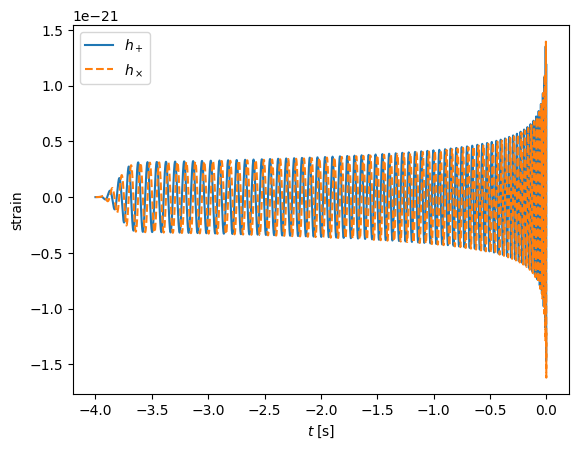

In [3]:
N = int(4.0 * 2048)
time = jnp.arange(N) / 2048 - 4.0  # -4 s to 0 s, merger at end

hp_td, hc_td = model.get_waveform_td(time, params)

plt.plot(time, hp_td, label=r"$h_+$")
plt.plot(time, hc_td, label=r"$h_\times$", ls="--")
plt.xlabel(r"$t\;[\mathrm{s}]$")
plt.ylabel("strain")
plt.legend()
plt.show()

## Frequency-domain waveform

`get_waveform_fd` windows the time-domain signal and applies an FFT internally. It returns the plus and cross polarizations over positive frequencies up to the Nyquist frequency.

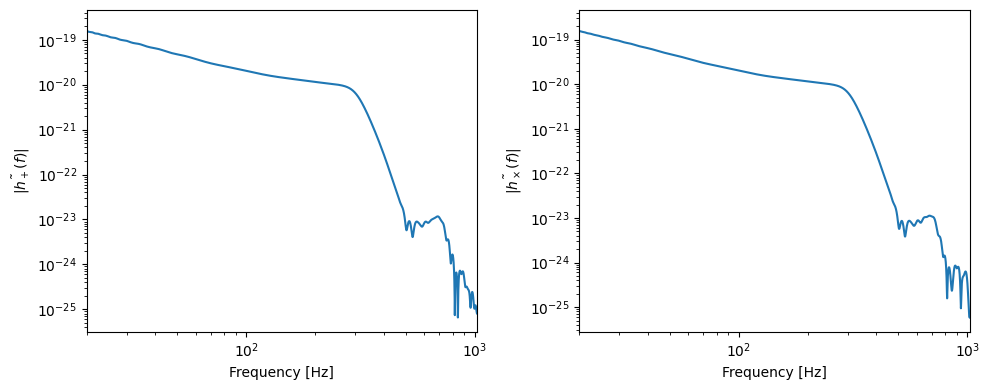

In [4]:
hp_fd, hc_fd = model.get_waveform_fd(params)

# Frequency axis
freqs = jnp.fft.rfftfreq(N, 1.0 / 2048)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, h, pol in zip(axes, [hp_fd, hc_fd], [r"h_+", r"h_\times"]):
    ax.loglog(freqs[1:], jnp.abs(h[1:]))
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel(rf"$|\tilde{{{pol}}}(f)|$")
    ax.set_xlim(20, 1024)
plt.tight_layout()
plt.show()

## Gradient through the frequency-domain waveform

Because `get_waveform_fd` is a pure JAX function, you can differentiate through it directly:

In [5]:
import equinox as eqx

def snr_proxy(params):
    hp_fd, _ = model.get_waveform_fd(params)
    return jnp.sum(jnp.abs(hp_fd) ** 2)

grad = eqx.filter_jit(eqx.filter_grad(snr_proxy))(params)
print("gradient w.r.t. [M_tot, dist_mpc, iota, phase_c, q, chi1z, chi2z]:")
print(grad)

gradient w.r.t. [M_tot, dist_mpc, iota, phase_c, q, chi1z, chi2z]:
[ 7.62660308e-38 -9.29291003e-39 -1.44609882e-36  2.09444505e-39
 -2.29623778e-37  1.42706282e-37  1.13279046e-37]
